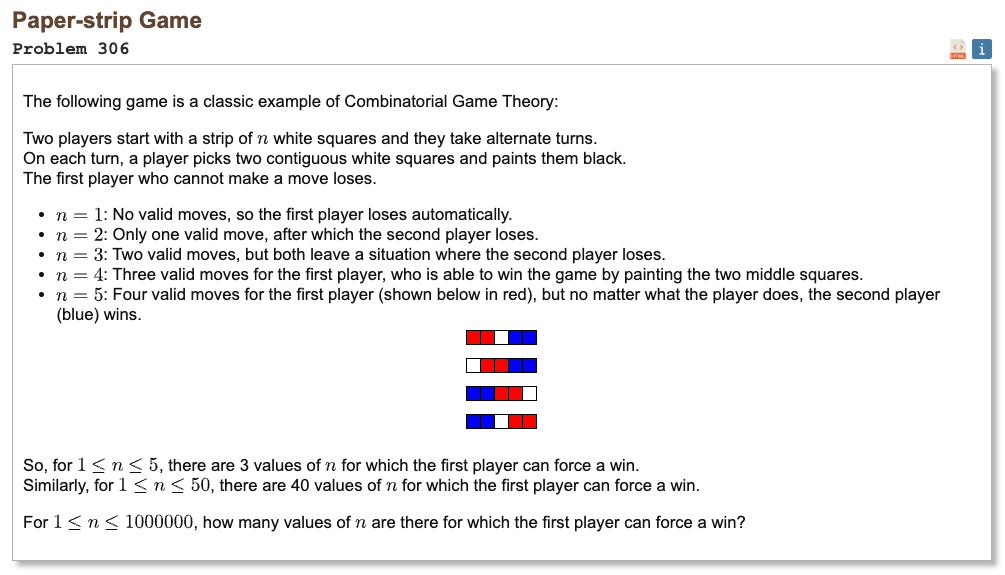

## Initial approach

* model each white strip length as a separate game state
* a move paints two neighboring squares and splits the strip into left and right parts
* combine the two remaining parts using xor because they are independent games
* calculate the mex value for each strip length
* a strip is winning when its game value is not zero
* after checking enough values, the win and loss pattern becomes periodic
* use the period to count up to one million instead of computing every state

In [1]:
def mex(values):
    x = 0
    while x in values:
        x += 1
    return x

def build_grundy(limit):
    grundy = [0] * (limit + 1)

    for n in range(2, limit + 1):
        reachable = set()

        for left in range(n - 1):
            right = n - left - 2
            reachable.add(grundy[left] ^ grundy[right])

        grundy[n] = mex(reachable)

    return grundy

def solve(limit):
    check_limit = 200
    grundy = build_grundy(check_limit)

    winning = [False] * (check_limit + 1)
    for n in range(1, check_limit + 1):
        winning[n] = grundy[n] != 0

    period_start = 36
    period = 34

    if limit < period_start:
        return sum(winning[1:limit + 1])

    total = sum(winning[1:period_start])

    block_wins = sum(winning[period_start:period_start + period])
    remaining = limit - period_start + 1

    full_blocks = remaining // period
    leftover = remaining % period

    total += full_blocks * block_wins
    total += sum(winning[period_start:period_start + leftover])

    return total

In [2]:
%%time
result = solve(10 ** 6)
print("Result:", result)

Result: 852938
CPU times: user 2.15 ms, sys: 56 μs, total: 2.2 ms
Wall time: 2.18 ms
